# Expert vs Predicted Affinity Confusion Matrix

This notebook compares expert labels against predicted labels for the same `(Abstract_Index, RA2025_ID)` pairs.

Metrics included:
1. Confusion matrix against expert labels
2. Per-class recall
3. Quadratic Weighted Kappa
4. Mean signed error
5. Reliability curve

- Expert source: `calibration_abstract_question_affinities.csv`
- Pred source: `adjudicated_ra_affinities.csv`

The expert `Expert_Affinity_Level` score is mapped to `Low` / `Moderate` / `High` using the same thresholds as the project adjudication code.

In [28]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, cohen_kappa_score, accuracy_score

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['figure.dpi'] = 120

In [29]:
repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
expert_root = repo_root / "data" / "results" / "affinity_calibration"
pred_root = repo_root / "data" / "results" / "affinity_benchmark"

# expert_run_dir_names = ["20260618_Mark_batch1_v2"]
expert_run_dir_names = ["20260618_Mark_batch1_v4"]
# pred_run_dir_names = ["20260422_212121_1", "20260422_212121_4","20260422_212121_3"]
# pred_run_dir_names = ["20260713_143513"]
pred_run_dir_names = ["20260721_124821"]
expert_input_filename = "calibration_abstract_question_affinities.csv"
pred_input_filename = "adjudicated_ra_affinities.csv"

LABEL_ORDER = ["Low", "Moderate", "High"]
LABEL_TO_NUM = {"Low": 0, "Moderate": 1, "High": 2}
NUM_TO_LABEL = {0: "Low", 1: "Moderate", 2: "High"}

expert_label_col = "Evaluator_Affinity_Level"
pred_score_col = "Final_Affinity"

# Optional metric 5 inputs.
agreement_strength_col = "agreement_mean"#"agreement_mean"
panel_vote_cols = []


def load_table(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".csv":
        for encoding in ("utf-8-sig", "utf-8", "cp1252", "latin1"):
            try:
                return pd.read_csv(path, encoding=encoding)
            except UnicodeDecodeError:
                continue
        raise UnicodeDecodeError(
            "utf-8", b"", 0, 1, f"Unable to decode CSV file: {path}"
        )
    if path.suffix.lower() in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    raise ValueError(f"Unsupported file extension for {path}")

def collect_frames(root: Path, run_dir_names, input_filename: str, source_name: str):
    if isinstance(run_dir_names, (str, Path)):
        run_dir_names = [run_dir_names]

    run_dirs = sorted([p for p in root.iterdir() if p.is_dir()])
    if not run_dirs:
        raise FileNotFoundError(f"No run directories found under {root}")

    selected_run_dirs = [p for p in run_dirs if p.name in {str(x) for x in run_dir_names}]
    if not selected_run_dirs:
        raise FileNotFoundError(f"No matching run directories found for: {run_dir_names}")

    frames = []
    for run_dir in selected_run_dirs:
        input_path = run_dir / input_filename
        if not input_path.exists():
            raise FileNotFoundError(f"Missing file: {input_path}")

        run_df = load_table(input_path)
        run_df["Run_ID"] = run_dir.name
        run_df["Source_Type"] = source_name
        frames.append(run_df)

    return frames, selected_run_dirs

def normalize_level(value):
    if pd.isna(value):
        return np.nan

    if isinstance(value, str):
        text = value.strip().lower()
        if text in {"low", "moderate", "high"}:
            return text.capitalize()
        return np.nan

    if isinstance(value, (int, float, np.integer, np.floating)):
        score = float(value)
        if 0 <= score <= 40:
            return "Low"
        if 40 < score <= 80:
            return "Moderate"
        if 80 < score <= 120:
            return "High"

    return np.nan

In [30]:
expert_frames, selected_expert_dirs = collect_frames(
    expert_root, expert_run_dir_names, expert_input_filename, "expert"
)
pred_frames, selected_pred_dirs = collect_frames(
    pred_root, pred_run_dir_names, pred_input_filename, "pred"
)

expert_df = pd.concat(expert_frames, ignore_index=True)
pred_df = pd.concat(pred_frames, ignore_index=True)
merged_df = pd.merge(
    expert_df,
    pred_df,
    on=["Abstract_Index", "RA2025_ID"],
    how="inner",
    suffixes=("_expert", "_pred"),
)

if expert_label_col not in merged_df.columns:
    raise ValueError(f"Could not find expert label column '{expert_label_col}'.")
if pred_score_col not in merged_df.columns:
    raise ValueError(f"Could not find pred score column '{pred_score_col}'.")

merged_df["expert_level"] = merged_df[expert_label_col].apply(normalize_level)
# merged_df["expert_level"] = merged_df[expert_label_col]

merged_df["pred_level"] = merged_df[pred_score_col].apply(normalize_level)

clean_df = merged_df.dropna(subset=["expert_level", "pred_level"]).copy()
clean_df["expert_num"] = clean_df["expert_level"].map(LABEL_TO_NUM).astype(int)
clean_df["pred_num"] = clean_df["pred_level"].map(LABEL_TO_NUM).astype(int)

print("Expert run directories:", [p.name for p in selected_expert_dirs])
print("Pred run directories:", [p.name for p in selected_pred_dirs])
print("Expert rows loaded:", len(expert_df))
print("Pred rows loaded:", len(pred_df))
print("Rows after inner merge:", len(merged_df))
print("Rows after label cleaning:", len(clean_df))
print(f'Unique abstract indices: {clean_df.Abstract_Index.unique().size:,}')
print("Expert label distribution:")
display(clean_df["expert_level"].value_counts().reindex(LABEL_ORDER, fill_value=0).to_frame("count"))
print("Pred label distribution:")
display(clean_df["pred_level"].value_counts().reindex(LABEL_ORDER, fill_value=0).to_frame("count"))
display(clean_df[["Abstract_Index", "RA2025_ID", expert_label_col, pred_score_col, "expert_level", "pred_level"]].head(10))

Expert run directories: ['20260618_Mark_batch1_v4']
Pred run directories: ['20260721_124821']
Expert rows loaded: 130
Pred rows loaded: 1008
Rows after inner merge: 130
Rows after label cleaning: 130
Unique abstract indices: 21
Expert label distribution:


,count
expert_level,
Low,67
Moderate,49
High,14


Pred label distribution:


,count
pred_level,
Low,80
Moderate,35
High,15


,Abstract_Index,RA2025_ID,Evaluator_Affinity_Level,Final_Affinity,expert_level,pred_level
0,10.1109/TPWRS.2023.3234277,23,Low,30.00,Low,Low
1,10.1109/TPWRS.2023.3234277,24,Moderate,28.00,Moderate,Low
2,10.1109/TPWRS.2023.3234277,27,Moderate,48.00,Moderate,Moderate
3,10.1109/TPWRS.2023.3234277,35,Low,15.75,Low,Low
4,10.1109/TPWRS.2023.3234277,37,Moderate,30.00,Moderate,Low
5,10.1109/TPWRS.2023.3234277,39,Low,22.00,Low,Low
6,10.1109/TPWRS.2023.3234277,41,High,85.00,High,High
7,10.1109/TPWRS.2023.3234277,42,Moderate,82.00,Moderate,High
8,10.1109/TPWRS.2023.3234277,43,Moderate,28.00,Moderate,Low
9,10.1109/TPWRS.2023.3234277,47,Low,25.00,Low,Low


,Pred Low,Pred Moderate,Pred High
Expert Low,54,11,2
Expert Moderate,26,19,4
Expert High,0,5,9


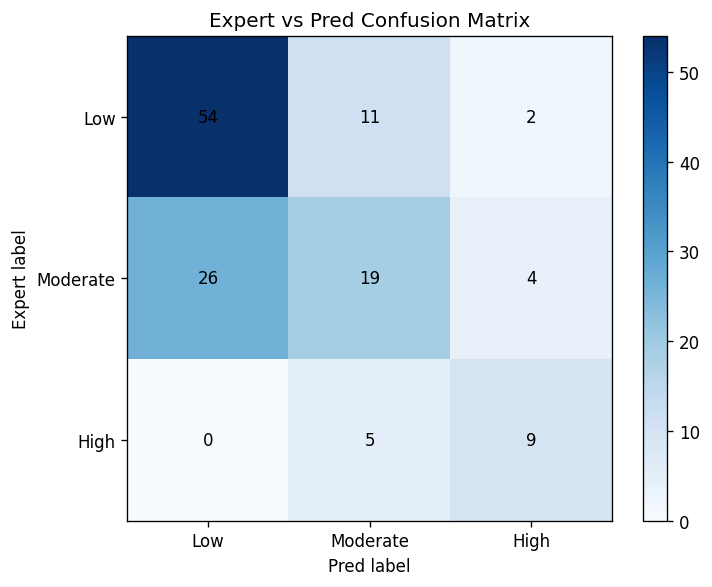

In [31]:
y_true = clean_df["expert_num"].to_numpy()
y_pred = clean_df["pred_num"].to_numpy()

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
cm_df = pd.DataFrame(
    cm,
    index=[f"Expert {label}" for label in LABEL_ORDER],
    columns=[f"Pred {label}" for label in LABEL_ORDER],
)
display(cm_df)

fig, ax = plt.subplots()
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(LABEL_ORDER)
ax.set_yticklabels(LABEL_ORDER)
ax.set_xlabel("Pred label")
ax.set_ylabel("Expert label")
ax.set_title("Expert vs Pred Confusion Matrix")

for row in range(cm.shape[0]):
    for col in range(cm.shape[1]):
        ax.text(col, row, str(cm[row, col]), ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## Metric 2: Per-Class Recall

In [32]:
recalls = recall_score(y_true, y_pred, labels=[0, 1, 2], average=None, zero_division=0)
recall_df = pd.DataFrame({
    'Class': LABEL_ORDER,
    'Recall': recalls,
    'Interpretation': [
        'Ability to identify low-affinity pairs',
        'Ability to identify medium-affinity pairs',
        'Ability to identify high-affinity pairs',
    ],
})
display(recall_df)

,Class,Recall,Interpretation
0,Low,0.805970,Ability to identify low-affinity pairs
1,Moderate,0.387755,Ability to identify medium-affinity pairs
2,High,0.642857,Ability to identify high-affinity pairs


## Metric 2b: Per-Class Precision

In [33]:
precisions = precision_score(y_true, y_pred, labels=[0, 1, 2], average=None, zero_division=0)
precision_df = pd.DataFrame({
    'Class': LABEL_ORDER,
    'Precision': precisions,
    'Interpretation': [
        'Purity of predicted low-affinity pairs',
        'Purity of predicted medium-affinity pairs',
        'Purity of predicted high-affinity pairs',
    ],
})
display(precision_df)

,Class,Precision,Interpretation
0,Low,0.675000,Purity of predicted low-affinity pairs
1,Moderate,0.542857,Purity of predicted medium-affinity pairs
2,High,0.600000,Purity of predicted high-affinity pairs


## Metric 3 and 4: Quadratic Weighted Kappa and Mean Signed Error

In [34]:
qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
mean_signed_error = float(np.mean(y_pred - y_true))

print(f'Quadratic Weighted Kappa = {qwk:.4f}')
print(f'Mean signed error        = {mean_signed_error:.4f}')

Quadratic Weighted Kappa = 0.5610
Mean signed error        = -0.0923


## Metric 5: Reliability Curve

/tmp/ipykernel_10196/2585440649.py:44: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: pd.Series({
/tmp/ipykernel_10196/2585440649.py:54: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: pd.Series({


,agreement_strength,n_cases,accuracy
0,0.333333,6.0,0.833333
1,0.500000,83.0,0.578313
2,1.000000,41.0,0.707317


,agreement_strength,expert_level,n_cases,accuracy
2,0.500000,High,11.0,0.545455
5,1.000000,High,3.0,1.000000
0,0.333333,Low,4.0,1.000000
3,0.500000,Low,40.0,0.675000
6,1.000000,Low,23.0,1.000000
1,0.333333,Moderate,2.0,0.500000
4,0.500000,Moderate,32.0,0.468750
7,1.000000,Moderate,15.0,0.200000


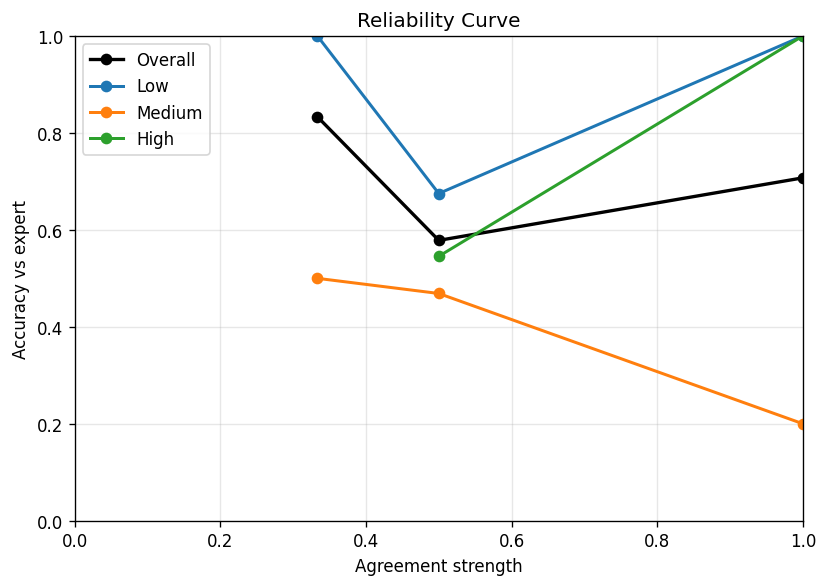

In [35]:
reliability_df = None
reliability_by_level_df = True

def compute_agreement_strength(row, pred_col_name, vote_cols):
    final_label = normalize_level(row[pred_col_name])
    votes = row[vote_cols].dropna()
    if len(votes) == 0:
        return np.nan
    votes_clean = votes.map(normalize_level)
    votes_clean = votes_clean.dropna()
    if len(votes_clean) == 0 or pd.isna(final_label):
        return np.nan
    return float((votes_clean == final_label).sum() / len(votes_clean))

if agreement_strength_col is not None and agreement_strength_col in clean_df.columns:
    work = clean_df.copy()
    work['agreement_strength'] = pd.to_numeric(work[agreement_strength_col], errors='coerce')
elif panel_vote_cols:
    missing_votes = [c for c in panel_vote_cols if c not in clean_df.columns]
    if missing_votes:
        print(f'Skipping reliability curve: missing panel vote columns: {missing_votes}')
        work = None
    else:
        work = clean_df.copy()
        work['agreement_strength'] = work.apply(
            compute_agreement_strength, axis=1, args=("pred_level", panel_vote_cols)
        )
else:
    print('Skipping reliability curve: set agreement_strength_col or panel_vote_cols to compute it.')
    work = None

if work is not None:
    rel = work.dropna(subset=['agreement_strength']).copy()
    rel = rel[(rel['agreement_strength'] >= 0.0) & (rel['agreement_strength'] <= 1.0)].copy()

    if len(rel) == 0:
        print('Skipping reliability curve: no usable agreement strength values in [0, 1].')
    else:
        rel['agreement_strength'] = rel['agreement_strength'].astype(float)
        rel['is_correct'] = (rel['pred_num'] == rel['expert_num']).astype(int)

        reliability_df = (
            rel.groupby('agreement_strength', observed=False)
            .apply(lambda group: pd.Series({
                'n_cases': len(group),
                'accuracy': accuracy_score(group['expert_num'], group['pred_num']),
            }))
            .reset_index()
            .sort_values('agreement_strength')
        )

        reliability_by_level_df = (
            rel.groupby(['agreement_strength', 'expert_level'], observed=False)
            .apply(lambda group: pd.Series({
                'n_cases': len(group),
                'accuracy': accuracy_score(group['expert_num'], group['pred_num']),
            }))
            .reset_index()
            .sort_values(['expert_level', 'agreement_strength'])
        )

        display(reliability_df[['agreement_strength', 'n_cases', 'accuracy']])
        display(reliability_by_level_df[['agreement_strength', 'expert_level', 'n_cases', 'accuracy']])

        fig, ax = plt.subplots()
        ax.plot(
            reliability_df['agreement_strength'],
            reliability_df['accuracy'],
            marker='o',
            color='black',
            linewidth=2,
            label='Overall',
        )

        level_display_order = ['Low', 'Moderate', 'High']
        level_display_labels = {'Low': 'Low', 'Moderate': 'Medium', 'High': 'High'}
        level_colors = {'Low': '#1f77b4', 'Moderate': '#ff7f0e', 'High': '#2ca02c'}

        for level in level_display_order:
            level_df = reliability_by_level_df[reliability_by_level_df['expert_level'] == level]
            if level_df.empty:
                continue
            ax.plot(
                level_df['agreement_strength'],
                level_df['accuracy'],
                marker='o',
                linewidth=1.8,
                label=level_display_labels[level],
                color=level_colors[level],
            )

        ax.set_xlabel('Agreement strength')
        ax.set_ylabel('Accuracy vs expert')
        ax.set_title('Reliability Curve')
        ax.set_ylim(0, 1)
        ax.set_xlim(0, 1)
        ax.grid(alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()

## Notes

If you want to compare a different pred run, change `pred_run_dir_names` in the setup cell. The confusion matrix uses the shared ordinal bins `Low`, `Moderate`, and `High`.

In [36]:
clean_df

,Abstract_Index,Abstract_Index_Old,Document Title_expert,RA2025_ID,RA_Question_expert,Evaluator_Affinity,Evaluator_Affinity_Level,Evaluator_Affinity_Reason,Source_Evaluator,Run_ID_expert,...,Final_Reason,Final_Method,Model_Slug,Cosine_x100_Mean,Run_ID_pred,Source_Type_pred,expert_level,pred_level,expert_num,pred_num
0,10.1109/TPWRS.2023.3234277,1,Scenario Reduction Network Based on Wasserstei...,23,What is the best way to integrate large datase...,30,Low,NaN,Mark,20260618_Mark_batch1_v4,...,One model emphasized the data-driven neural-ne...,adjudicated_llm,gpt-5.4,15.8090,20260721_124821,pred,Low,Low,0,0
1,10.1109/TPWRS.2023.3234277,1,Scenario Reduction Network Based on Wasserstei...,24,How can the risk of high-impact low-probabilit...,50,Moderate,NaN,Mark,20260618_Mark_batch1_v4,...,The conflict came from one model emphasizing p...,adjudicated_llm,gpt-5.4,32.3158,20260721_124821,pred,Moderate,Low,1,0
2,10.1109/TPWRS.2023.3234277,1,Scenario Reduction Network Based on Wasserstei...,27,How can risk-based methods (e.g. probabilistic...,50,Moderate,NaN,Mark,20260618_Mark_batch1_v4,...,This is one of the better indirect matches: th...,adjudicated_llm,gpt-5.4,25.5051,20260721_124821,pred,Moderate,Moderate,1,1
3,10.1109/TPWRS.2023.3234277,1,Scenario Reduction Network Based on Wasserstei...,35,"What models and methods, including testing, ar...",30,Low,NaN,Mark,20260618_Mark_batch1_v4,...,NaN,ensemble_mean,NaN,34.7981,20260721_124821,pred,Low,Low,0,0
4,10.1109/TPWRS.2023.3234277,1,Scenario Reduction Network Based on Wasserstei...,37,What studies and metrics are required to ident...,50,Moderate,NaN,Mark,20260618_Mark_batch1_v4,...,All models saw partial relevance through uncer...,adjudicated_llm,gpt-5.4,25.6859,20260721_124821,pred,Moderate,Low,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,10.1109/TPWRS.2023.3328161,185,Practical Methods of Defective Input Feature C...,26,What improvements can be made to predictive to...,0,Low,NaN,Mark,20260618_Mark_batch1_v4,...,This is a moderate match: the methods improve ...,adjudicated_llm,gpt-5.4,25.3027,20260721_124821,pred,Low,Moderate,0,1
126,10.1109/TPWRS.2023.3279323,280,Cyber-Physical Attack Launched From EVSE Botnet,15,"What aggregate quantities must be monitored, s...",0,Low,NaN,Mark,20260618_Mark_batch1_v4,...,The paper analyzes aggregate distributed EVSE ...,adjudicated_llm,gpt-5.4,20.1380,20260721_124821,pred,Low,Low,0,0
127,10.1109/TPWRS.2023.3279323,280,Cyber-Physical Attack Launched From EVSE Botnet,16,What is the communication capability needed to...,0,Low,NaN,Mark,20260618_Mark_batch1_v4,...,This is one of the strongest matches. All mode...,adjudicated_llm,gpt-5.4,35.6585,20260721_124821,pred,Low,High,0,2
128,10.1109/TPWRS.2023.3279323,280,Cyber-Physical Attack Launched From EVSE Botnet,17,What is a scalable data architecture for DER m...,0,Low,NaN,Mark,20260618_Mark_batch1_v4,...,The paper concerns distributed coordination of...,adjudicated_llm,gpt-5.4,31.9007,20260721_124821,pred,Low,Low,0,0
